<a href="https://colab.research.google.com/github/Sarasii22/Google-Colab-Examples/blob/main/Question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(1) In this problem, we apply N-fold cross-validation to determine the optimal value of
�
�for k-Nearest Neighbors (k-NN) regression using the Paddy dataset, available at:
https://archive.ics.uci.edu/dataset/1186/paddy+dataset.
(i) What is the target variable of the regression problem?
(ii) How many input features are present in the dataset?
(iii) How should categorical features be handled in this dataset?
(iv) How is feature scaling performed, and why is it important for k-NN regression?
(v) Perform 5-fold cross-validation for k-NN regression considering values of 𝑘from 1 to
20.
(vi) Plot 𝑘versus Mean Squared Error (MSE).
(vii) Based on the results, identify the optimal value of 𝑘and justify your choice.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/drive/MyDrive/ML/paddydataset.csv")
df.head()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [6]:
num_input_features = df.shape[1] - 1
print(f"The dataset has {num_input_features} input features (excluding the target variable 'Paddy yield(in Kg)').")

The dataset has 44 input features (excluding the target variable 'Paddy yield(in Kg)').


In [7]:
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns and their unique values/counts:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    unique_values = df[col].unique()
    num_unique = len(unique_values)
    print(f"Number of unique values: {num_unique}")
    if num_unique <= 20: # Display unique values if there are not too many
        print(f"Unique values: {unique_values}")
    else:
        print("Too many unique values to display all.")


Categorical Columns and their unique values/counts:

Column: Agriblock
Number of unique values: 6
Unique values: ['Cuddalore' 'Kurinjipadi' 'Panruti' 'Kallakurichi' 'Sankarapuram'
 'Chinnasalem']

Column: Variety
Number of unique values: 3
Unique values: ['CO_43' 'ponmani' 'delux ponni']

Column: Soil Types
Number of unique values: 2
Unique values: ['alluvial' 'clay']

Column: Nursery
Number of unique values: 2
Unique values: ['dry' 'wet']

Column: Wind Direction_D1_D30
Number of unique values: 6
Unique values: ['SW' 'NW' 'ENE' 'W' 'SSE' 'E']

Column: Wind Direction_D31_D60
Number of unique values: 5
Unique values: ['W' 'S' 'NE' 'WNW' 'ENE']

Column: Wind Direction_D61_D90
Number of unique values: 5
Unique values: ['NNW' 'SE' 'NNE' 'SW' 'NE']

Column: Wind Direction_D91_D120
Number of unique values: 6
Unique values: ['WSW' 'SSE' 'W' 'S' 'NW' 'NNW']


In [8]:
# Find categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [9]:
# Get unique categories for each
result = {}
for col in cat_cols:
    result[col] = df[col].unique().tolist()

In [10]:
# Display the result
print("Categorical Columns and Their Categories:")
for col, categories in result.items():
    print(f"- {col}: {categories}")

Categorical Columns and Their Categories:
- Agriblock: ['Cuddalore', 'Kurinjipadi', 'Panruti', 'Kallakurichi', 'Sankarapuram', 'Chinnasalem']
- Variety: ['CO_43', 'ponmani', 'delux ponni']
- Soil Types: ['alluvial', 'clay']
- Nursery: ['dry', 'wet']
- Wind Direction_D1_D30: ['SW', 'NW', 'ENE', 'W', 'SSE', 'E']
- Wind Direction_D31_D60: ['W', 'S', 'NE', 'WNW', 'ENE']
- Wind Direction_D61_D90: ['NNW', 'SE', 'NNE', 'SW', 'NE']
- Wind Direction_D91_D120: ['WSW', 'SSE', 'W', 'S', 'NW', 'NNW']


In [11]:
df.describe

<bound method NDFrame.describe of       Hectares      Agriblock      Variety Soil Types  Seedrate(in Kg)  \
0             6     Cuddalore        CO_43   alluvial              150   
1             6   Kurinjipadi      ponmani       clay              150   
2             6       Panruti  delux ponni   alluvial              150   
3             6  Kallakurichi        CO_43       clay              150   
4             6  Sankarapuram      ponmani   alluvial              150   
...         ...           ...          ...        ...              ...   
2784          1  Kallakurichi        CO_43   alluvial               25   
2785          1  Sankarapuram      ponmani       clay               25   
2786          1   Chinnasalem  delux ponni       clay               25   
2787          1     Cuddalore        CO_43   alluvial               25   
2788          1   Kurinjipadi  delux ponni       clay               25   

      LP_Mainfield(in Tonnes) Nursery  Nursery area (Cents)  \
0                        75.0     dry                   120   
1                        75.0     wet                   120   
2                        75.0     dry                   120   
3                        75.0     wet                   120   
4                        75.0     dry                   120   
...                       ...     ...                   ...   
2784                     12.5     wet                    20   
2785                     12.5     wet                    20   
2786                     12.5     wet                    20   
2787                     12.5     wet                    20   
2788                     12.5     wet                    20   

      LP_nurseryarea(in Tonnes)  DAP_20days  ...  Wind Direction_D1_D30  \
0                             6         240  ...                     SW   
1                             6         240  ...                     NW   
2                             6         240  ...                    ENE   
3                             6         240  ...                      W   
4                             6         240  ...                    SSE   
...                         ...         ...  ...                    ...   
2784                          1          40  ...                      W   
2785                          1          40  ...                    SSE   
2786                          1          40  ...                      E   
2787                          1          40  ...                     SW   
2788                          1          40  ...                     NW   

      Wind Direction_D31_D60  Wind Direction_D61_D90  Wind Direction_D91_D120  \
0                          W                     NNW                      WSW   
1                          S                      SE                      SSE   
2                         NE                     NNE                        W   
3                        WNW                      SE                        S   
4                          W                      SW                       NW   
...                      ...                     ...                      ...   
2784                     WNW                      SE                        S   
2785                       W                      SW                       NW   
2786                     ENE                      NE                      NNW   
2787                       W                     NNW                      WSW   
2788                       S                      SE                      SSE   

      Relative Humidity_D1_D30  Relative Humidity_D31_D60  \
0                         72.0                         78   
1                         64.6                         85   
2                         85.0                         96   
3                         88.5                         95   
4                         72.7                         91   
...                        ...                        ...   
2784               

In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Identify numerical features for scaling.
# Exclude target variable 'Paddy yield(in Kg)' and already one-hot encoded 'Agriblock' and 'Variety' columns
# and other categorical columns which will be one hot encoded later.

# First, identify all non-numeric columns that are not already dummy variables.
# We need to consider that some columns might have been dropped or converted.

# Get current object type columns
object_cols = df.select_dtypes(include='object').columns.tolist()

# Get numerical columns by excluding object columns and the target variable
# Ensure the target variable is indeed numeric or handle it appropriately if not
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Paddy yield(in Kg)' in numerical_cols:
    numerical_cols.remove('Paddy yield(in Kg)')

# Drop other categorical columns if they are still in numerical_cols (e.g., if they were numeric originally)
# This is a safeguard, but typically select_dtypes(include='object') handles string categoricals.
# Let's verify the current state of df to make a precise list.

# To be precise, let's reconstruct the list of columns to scale.
# Start with all columns, remove the target, and then remove non-numerical categorical columns that are not yet encoded.

# Ensure we have the latest df for column identification
# If df was reloaded earlier, 'Agriblock' and 'Variety' would be back as object types.
# Let's check the current state of 'df' and proceed.

# Get all columns from the current DataFrame
all_columns = df.columns.tolist()

# Exclude the target variable
features_to_scale = [col for col in all_columns if col != 'Paddy yield(in Kg)']

# Exclude boolean (dummy) columns and string (object) columns that are not yet encoded
# The booleans (from get_dummies) are already in a numerical form (False/True -> 0/1).
# We want to scale continuous numerical features.

# Re-identifying the columns to scale: all numeric columns except target and boolean dummies.
# Boolean columns are typically not scaled as they are already 0 or 1.
# However, if there are numeric columns that represent ordinal categories or are counts, they should be scaled.

# Let's consider only numerical columns (int/float) that are not the target variable.
# We will exclude the boolean (dummy) columns from scaling as they are already 0/1 and represent a specific state.

# Identify columns that are not object (string) and not boolean (dummy from get_dummies) and not the target.
columns_for_scaling = []
for col in df.columns:
    if df[col].dtype != 'object' and col != 'Paddy yield(in Kg)' and not pd.api.types.is_bool_dtype(df[col]):
        columns_for_scaling.append(col)


print(f"Columns selected for scaling: {columns_for_scaling}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical features
df[columns_for_scaling] = scaler.fit_transform(df[columns_for_scaling])

print("\nDataFrame after feature scaling (first 5 rows of scaled columns):")
display(df[columns_for_scaling].head())


Columns selected for scaling: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120', 'Trash(in bundles)']

DataFrame after feature scaling (first 5 rows of scaled columns):


,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,...,Max temp_D91_D120,Inst Wind Speed_D1_D30(in Knots),Inst Wind Speed_D31_D60(in Knots),Inst Wind Speed_D61_D90(in Knots),Inst Wind Speed_D91_D120(in Knots),Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles)
0,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,...,0.198146,-1.260056,0.464322,-0.086704,0.218875,-0.532122,-1.415997,0.813232,0.363892,1.522734
1,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,...,-1.473447,1.078132,-1.408861,0.916688,-1.370816,-1.457131,-0.382866,-0.332275,1.001991,1.969526
2,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,...,0.198146,-1.260056,1.088716,-2.093488,1.013720,1.092893,1.240625,-0.332275,-1.550403,1.969526
3,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,...,-0.136173,0.298736,-0.784467,-0.086704,-1.370816,1.530397,1.093035,-1.191405,0.044843,1.522734
4,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,...,1.535420,1.078132,1.088716,0.916688,1.013720,-0.444621,0.502674,-0.618652,-0.912305,1.969526


In [16]:
import pandas as pd

# Identify all remaining categorical columns (object dtype) after scaling
categorical_cols_to_encode = df.select_dtypes(include='object').columns.tolist()

# Apply one-hot encoding to these categorical columns
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# Separate features (X) and target variable (y)
X = df.drop('Paddy yield(in Kg)', axis=1)
y = df['Paddy yield(in Kg)']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 rows of y:")
display(y.head())

Shape of X (features): (2789, 63)
Shape of y (target): (2789,)

First 5 rows of X:


,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,...,Wind Direction_D91_D120_SSE,Wind Direction_D91_D120_W,Wind Direction_D91_D120_WSW,Agriblock_Cuddalore,Agriblock_Kallakurichi,Agriblock_Kurinjipadi,Agriblock_Panruti,Agriblock_Sankarapuram,Variety_delux ponni,Variety_ponmani
0,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,...,False,False,True,True,False,False,False,False,False,False
1,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,...,True,False,False,False,False,True,False,False,False,True
2,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,...,False,True,False,False,False,False,True,False,True,False
3,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,...,False,False,False,False,True,False,False,False,False,False
4,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,1.587832,...,False,False,False,False,False,False,False,True,False,True



First 5 rows of y:


,Paddy yield(in Kg)
0,35028
1,35412
2,36300
3,35016
4,34044


In [18]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score

# Initialize empty lists to store the R-squared and negative MSE scores for each k
r2_scores = []
mse_scores = []

# Loop through k values from 1 to 20
for k in range(1, 21):
    # Instantiate a KNeighborsRegressor object
    knn_regressor = KNeighborsRegressor(n_neighbors=k)

    # Initialize KFold for 5-fold cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Calculate cross-validation scores using R-squared as the metric
    r2_fold_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='r2')
    # Calculate cross-validation scores using negative mean squared error as the metric
    nmse_fold_scores = cross_val_score(knn_regressor, X, y, cv=kf, scoring='neg_mean_squared_error')

    # Calculate the mean of the R-squared scores for the current k
    mean_r2 = r2_fold_scores.mean()
    # Calculate the mean of the negative MSE scores for the current k (and convert to positive MSE)
    mean_mse = -nmse_fold_scores.mean()

    # Append the mean scores to their respective lists
    r2_scores.append(mean_r2)
    mse_scores.append(mean_mse)

# Print the list of R-squared scores
print("R-squared scores for k from 1 to 20:")
print(r2_scores)

# Print the list of MSE scores
print("\nMean Squared Error scores for k from 1 to 20:")
print(mse_scores)

R-squared scores for k from 1 to 20:
[np.float64(0.9846207701485812), np.float64(0.9882575227556663), np.float64(0.9893116210357048), np.float64(0.9901291002642638), np.float64(0.9906944176623685), np.float64(0.9910057282501574), np.float64(0.9910556497485526), np.float64(0.9911004036334369), np.float64(0.9912514118843674), np.float64(0.9913721053434259), np.float64(0.9914415220131557), np.float64(0.991531224192354), np.float64(0.991548697440978), np.float64(0.9915661110459897), np.float64(0.9916478142699446), np.float64(0.9916556495300938), np.float64(0.9916246388611587), np.float64(0.9916668449963717), np.float64(0.9916388289860653), np.float64(0.9916411250015911)]

Mean Squared Error scores for k from 1 to 20:
[np.float64(1297695.5824565806), np.float64(988995.319520537), np.float64(900961.3324613353), np.float64(831525.0537526625), np.float64(784213.9837400564), np.float64(757984.5878569483), np.float64(753714.9630072148), np.float64(750075.4553234272), np.float64(736840.979031253)

In [19]:
optimal_k_index = r2_scores.index(max(r2_scores))
optimal_k = optimal_k_index + 1
optimal_r2_score = r2_scores[optimal_k_index]

print(f"Optimal k: {optimal_k}")
print(f"Corresponding R-squared score: {optimal_r2_score}")

Optimal k: 18
Corresponding R-squared score: 0.9916668449963717


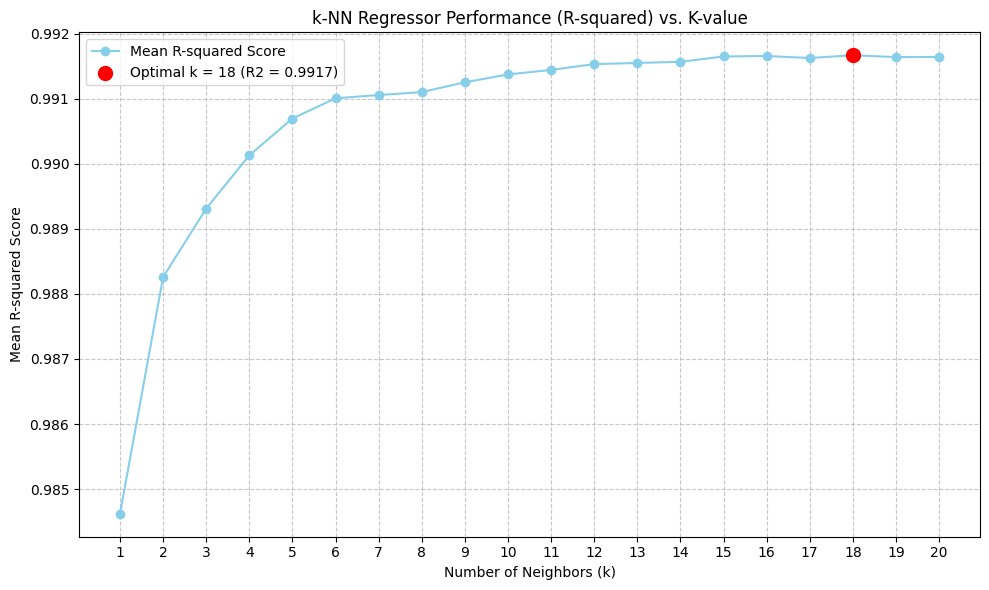

In [20]:
import matplotlib.pyplot as plt

# Create a list of k values from 1 to 20
k_values = list(range(1, 21))

# Plot the R-squared scores against k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, r2_scores, marker='o', linestyle='-', color='skyblue', label='Mean R-squared Score')

# Mark the optimal k
plt.scatter(optimal_k, optimal_r2_score, color='red', s=100, zorder=5, label=f'Optimal k = {optimal_k} (R2 = {optimal_r2_score:.4f})')

# Add title and labels
plt.title('k-NN Regressor Performance (R-squared) vs. K-value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean R-squared Score')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

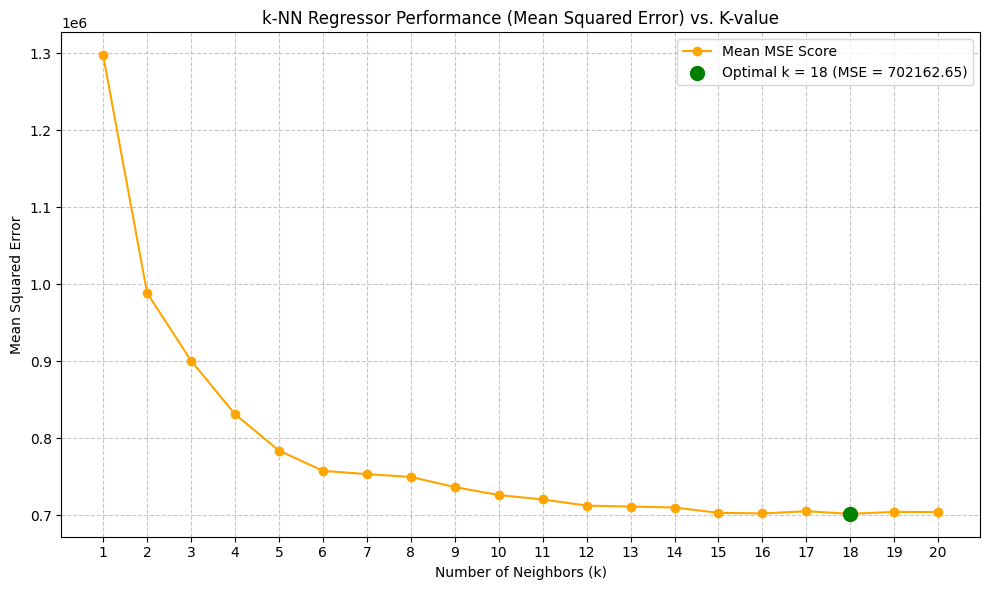

In [21]:
import matplotlib.pyplot as plt

# Create a list of k values from 1 to 20
k_values = list(range(1, 21))

# Find the optimal k based on minimizing MSE
optimal_mse_k_index = mse_scores.index(min(mse_scores))
optimal_mse_k = optimal_mse_k_index + 1
optimal_mse_score = mse_scores[optimal_mse_k_index]

# Plot the MSE scores against k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_scores, marker='o', linestyle='-', color='orange', label='Mean MSE Score')

# Mark the optimal k for MSE
plt.scatter(optimal_mse_k, optimal_mse_score, color='green', s=100, zorder=5, label=f'Optimal k = {optimal_mse_k} (MSE = {optimal_mse_score:.2f})')

# Add title and labels
plt.title('k-NN Regressor Performance (Mean Squared Error) vs. K-value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Squared Error')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()